# 03 — Slither.io gameplay prediction (connectome reservoir)

End-to-end pipeline: per-frame slither.io state tensors → features → **frozen connectome reservoir** states → ridge readout → predict the player's next steering angle (binned) and boost. Uses the `slither` package + `reservoirs.connectome`, running on the committed **mock** demo sessions and mock connectome (no private data needed).

In [1]:
import sys, os
from pathlib import Path
REPO = Path.cwd()
while not (REPO / 'reservoirs').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); os.chdir(REPO)
print('repo root set:', REPO.name)   # name only, no absolute path

repo root set: ESN-unofficial-1-utilizzando-matrici-random-con-iris


In [2]:
import warnings, numpy as np
from pathlib import Path
import slither
from reservoirs.connectome import ConnectomeReservoir
from slither.config import LEAK_RANGE, INPUT_SCALE, T_WASHOUT, ALPHA, WINDOW_LEN, WINDOW_STRIDE
DATA, GRAPH = Path('data'), Path('generated_artifacts/graphs')
slither.ensure_mock_graph(GRAPH); slither.ensure_mock_data(DATA)
X_list, y_list, names = slither.load_all_sessions(DATA)
u, y, sid = slither.make_windows(X_list, y_list, WINDOW_LEN, WINDOW_STRIDE)
print('sessions:', names, '| windows:', u.shape, '-> outputs', y.shape[-1])

sessions: ['session_1001', 'session_1002', 'session_1003'] | windows: (45, 25, 6149) -> outputs 18


### Train the readout and evaluate
We report both the original window-shuffled split **and** the leakage-free session-grouped split (overlapping windows share frames, so shuffling leaks; grouping by session is the honest protocol).

In [3]:
import pandas as pd
def run(group):
    u_tr,y_tr,u_te,y_te,_,_ = slither.train_test_split_windows(u,y,sid,seed=7,group_by_session=group)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        res = ConnectomeReservoir(n_inputs=u_tr.shape[2], graph_dir=str(GRAPH), edge_attr='weight',
            combine='mean', rhow=1.05, leak_range=LEAK_RANGE, symmetric=True, seed=7, input_scale=INPUT_SCALE)
    st = res.collect_states_batch   # Phase-5 vectorized fast path
    Xtr, Xte = st(u_tr), st(u_te)
    w = slither.compute_wout(Xtr, y_tr, washout=T_WASHOUT, alpha=ALPHA)
    out = []
    for split, P, Y in [('train', Xtr@w, y_tr), ('test', Xte@w, y_te)]:
        out.append({'split':split,'angle_acc':round(slither.angle_accuracy(P,Y),3),
                    'boost_acc':round(slither.boost_accuracy(P,Y),3),'mse':round(float(np.mean((P-Y)**2)),4)})
    return res, pd.DataFrame(out), (Xte@w, y_te)
res, m_leaky, _ = run(False); res, m_group, (pred_te, y_te) = run(True)
print('window-shuffled split (leaky):'); print(m_leaky.to_string(index=False))
print('\nsession-grouped split (leakage-free):'); print(m_group.to_string(index=False))
print('reservoir neurons:', res.n_neurons)

window-shuffled split (leaky):
split  angle_acc  boost_acc    mse
train      0.794      0.854 0.0195
 test      0.698      0.804 0.0273

session-grouped split (leakage-free):
split  angle_acc  boost_acc    mse
train      0.747      0.904 0.0197
 test      0.693      0.739 0.0643
reservoir neurons: 60


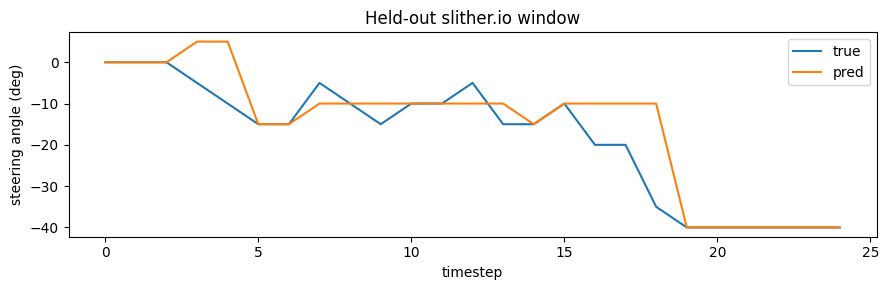

In [4]:
import matplotlib.pyplot as plt
from slither.config import ANGLE_MIN, ANGLE_MAX, ANGLE_RESOLUTION, NUM_ANGLE_BINS
angles = np.arange(ANGLE_MIN, ANGLE_MAX+ANGLE_RESOLUTION, ANGLE_RESOLUTION)
tb = y_te[0,:,:NUM_ANGLE_BINS].argmax(1); pb = pred_te[0,:,:NUM_ANGLE_BINS].argmax(1)
plt.figure(figsize=(9,3)); plt.plot(angles[tb], label='true'); plt.plot(angles[pb], label='pred')
plt.ylabel('steering angle (deg)'); plt.xlabel('timestep'); plt.legend()
plt.title('Held-out slither.io window'); plt.tight_layout(); plt.show()

**Notes:** numbers here are on **synthetic mock** data + a 60-node mock connectome, so they validate the pipeline, not a scientific claim. The leakage-free split shows the honest (higher) MSE. For real results: drop scraper sessions under `data/<user>/session_*` and a real connectome under `generated_artifacts/graphs/`.